# EDA

In [2]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_pickle('/triumvirate/home/celinaha/thesis_files/data/ml_datasets2/all_raw_samples.pkl')

### fixe outliers i plot

In [48]:
data['outliers_2'] = data['lipid_biomass_to_biomass'] / data['biomass_dilution']
data['outliers_2'] = data["outliers_2"].round(3)

deviating_rows = data[data["outliers_2"] != 0.134]

In [287]:
deviating_rows[deviating_rows['outlier'] != 1]

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2
1747,lcts_sample_562,0.116280,0.000664,0.004033,0.028808,0.000042,0.021830,0.184202,0.011365,0.000148,...,-2.608976,0.000000,0.000000,0.000000,0.000000,lcts,0,-0.010116,-0.113082,0.414
1875,lcts_sample_690,0.208110,0.001476,0.008964,0.064032,0.000106,0.023205,0.189115,0.016515,0.000314,...,-5.789543,0.000000,0.000000,0.000000,0.000000,lcts,0,-0.000733,-0.000693,0.293
1942,lcts_sample_757,0.273373,0.002012,0.012221,0.087299,0.000131,0.023212,0.097467,0.017527,0.000420,...,-7.677290,0.000000,0.000000,0.000000,0.000000,lcts,0,-0.000686,-0.000417,0.142
2948,succ_sample_397,0.239297,0.001601,0.009722,0.069435,0.000117,0.023158,0.079270,0.015041,0.000507,...,0.000000,0.000000,-32.239791,0.000000,0.000000,succ,0,-0.000801,0.000234,0.135
4399,arg_glyc_sample_89,0.307538,0.002445,0.014845,0.106055,0.000174,0.023323,0.104025,0.019738,0.000489,...,0.000000,-17.781804,0.000000,-12.976655,0.000000,arg_glyc,0,-0.000657,0.000007,0.135
4881,arg_glyc_sample_571,0.303191,0.002385,0.014484,0.103474,0.000170,0.023294,0.102395,0.019429,0.000476,...,0.000000,-18.026341,0.000000,-14.656151,0.000000,arg_glyc,0,-0.000646,0.000007,0.135
5393,nh4_glc_sample_430,0.309589,0.002509,0.015231,0.108827,0.000148,0.023389,0.118177,0.020301,0.000748,...,0.000000,0.000000,0.000000,0.000000,0.000000,nh4_glc,0,0.000039,-0.000714,0.149
5653,nh4_ac_sample_5,0.093756,0.000394,0.002394,0.017101,0.000014,0.013036,0.032101,0.005709,0.000138,...,0.000000,0.000000,0.000000,0.000000,0.000000,nh4_ac,0,0.000020,-0.001273,0.144
5789,nh4_ac_sample_141,0.118656,0.000548,0.003332,0.023795,0.000028,0.016259,0.040820,0.007293,0.000240,...,0.000000,0.000000,0.000000,0.000000,0.000000,nh4_ac,0,-0.001676,0.001122,0.143
5994,no3_glc_sample_55,0.078693,0.000312,0.001895,0.013542,0.000011,0.011042,0.028068,0.004798,0.000098,...,0.000000,0.000000,0.000000,0.000000,-1.967316,no3_glc,0,0.000016,-0.001288,0.150


In [49]:
mask = (
    (deviating_rows['outlier'] != 1) &
    (deviating_rows['outliers_2'] > 0.143)
)

samples_to_update = deviating_rows.loc[mask, 'sample']

data.loc[data['sample'].isin(samples_to_update), 'outlier'] = 1

In [50]:
data[data['outliers_2']>0.149]

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2
152,glc_sample_152,0.072573,0.000386,0.002345,0.016749,0.000032,0.020318,0.212064,0.009853,0.000077,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.000994,-0.000434,0.550
269,glc_sample_269,0.079072,0.000452,0.002742,0.019580,0.000040,0.021780,0.250824,0.011302,0.000094,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.000913,-0.000572,0.567
277,glc_sample_277,0.224226,0.001706,0.010356,0.073979,0.000125,0.023233,0.223305,0.018431,0.000363,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.000693,-0.000901,0.310
285,glc_sample_285,0.165884,0.001075,0.006527,0.046624,0.000075,0.023060,0.189800,0.014201,0.000211,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.000797,-0.000331,0.342
288,glc_sample_288,0.139277,0.000757,0.004595,0.032826,0.000038,0.020895,0.107061,0.010355,0.000153,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.010156,-0.057792,0.264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7189,no3_glyc_sample_528,0.085363,0.000411,0.002498,0.017846,0.000020,0.017495,0.123762,0.007970,0.000112,...,0.0,-20.190327,0.0,0.0,-2.434921,no3_glyc,1,0.000025,-0.001146,0.397
7212,no3_glyc_sample_551,0.135686,0.000698,0.004240,0.030295,0.000030,0.019460,0.074433,0.009206,0.000184,...,0.0,-27.457635,0.0,0.0,-3.574892,no3_glyc,1,0.000030,-0.001102,0.207
7213,no3_glyc_sample_552,0.040402,0.000149,0.000904,0.006462,0.000005,0.008669,0.059640,0.003749,0.000049,...,0.0,-22.011385,0.0,0.0,-1.126556,no3_glyc,1,0.000012,-0.001327,0.407
7228,no3_glyc_sample_567,0.243341,0.001697,0.010304,0.073623,0.000087,0.023200,0.106264,0.016071,0.000506,...,0.0,-22.718702,0.0,0.0,-6.593583,no3_glyc,1,0.000050,-0.000827,0.169


In [51]:
data['outlier'].value_counts()

outlier
0    6909
1     348
Name: count, dtype: int64

## BM plot

In [5]:
bm_plot = data.iloc[:, 1:12]
bm_plot.columns = bm_plot.columns.str.split('_').str[0]
bm_plot = bm_plot.rename(columns={'dummy': 'dummy protein'})

In [5]:
bm_plot

reaction,protein,mRNA,tRNA,rRNA,ncRNA,DNA,lipid,constituent,prosthetic,peptidoglycan,dummy protein
0,0.042196,0.000141,0.000857,0.006121,2.441456e-06,0.005740,0.012988,0.002476,0.000023,0.002546,0.000704
1,0.159765,0.000848,0.005154,0.036808,4.305130e-05,0.020290,0.051581,0.009831,0.000187,0.010112,0.002666
2,0.087971,0.000360,0.002186,0.015621,1.398394e-05,0.012089,0.027658,0.005272,0.000099,0.005422,0.001468
3,0.056537,0.000202,0.001228,0.008771,5.394236e-06,0.007733,0.017523,0.003340,0.000051,0.003435,0.000943
4,0.011679,0.000033,0.000203,0.001449,1.736281e-07,0.001567,0.003545,0.000676,0.000009,0.000695,0.000195
...,...,...,...,...,...,...,...,...,...,...,...
7252,0.086283,0.000350,0.002127,0.015199,1.019906e-05,0.011859,0.027109,0.005167,0.000133,0.005315,0.001440
7253,0.026028,0.000080,0.000487,0.003478,8.774053e-07,0.003517,0.007955,0.001516,0.000043,0.001560,0.000434
7254,0.063490,0.000233,0.001414,0.010105,5.044354e-06,0.008709,0.019759,0.003766,0.000229,0.003874,0.001059
7255,0.065260,0.000241,0.001466,0.010478,5.212395e-06,0.008956,0.020325,0.003874,0.000216,0.003985,0.001089


In [6]:
ex_rxns = ['EX_o2_e','EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e', 'EX_glyc_e', 'EX_succ_e', 'EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']

target_corr = bm_plot.copy()
target_corr[ex_rxns] = data[ex_rxns]

## Distributions

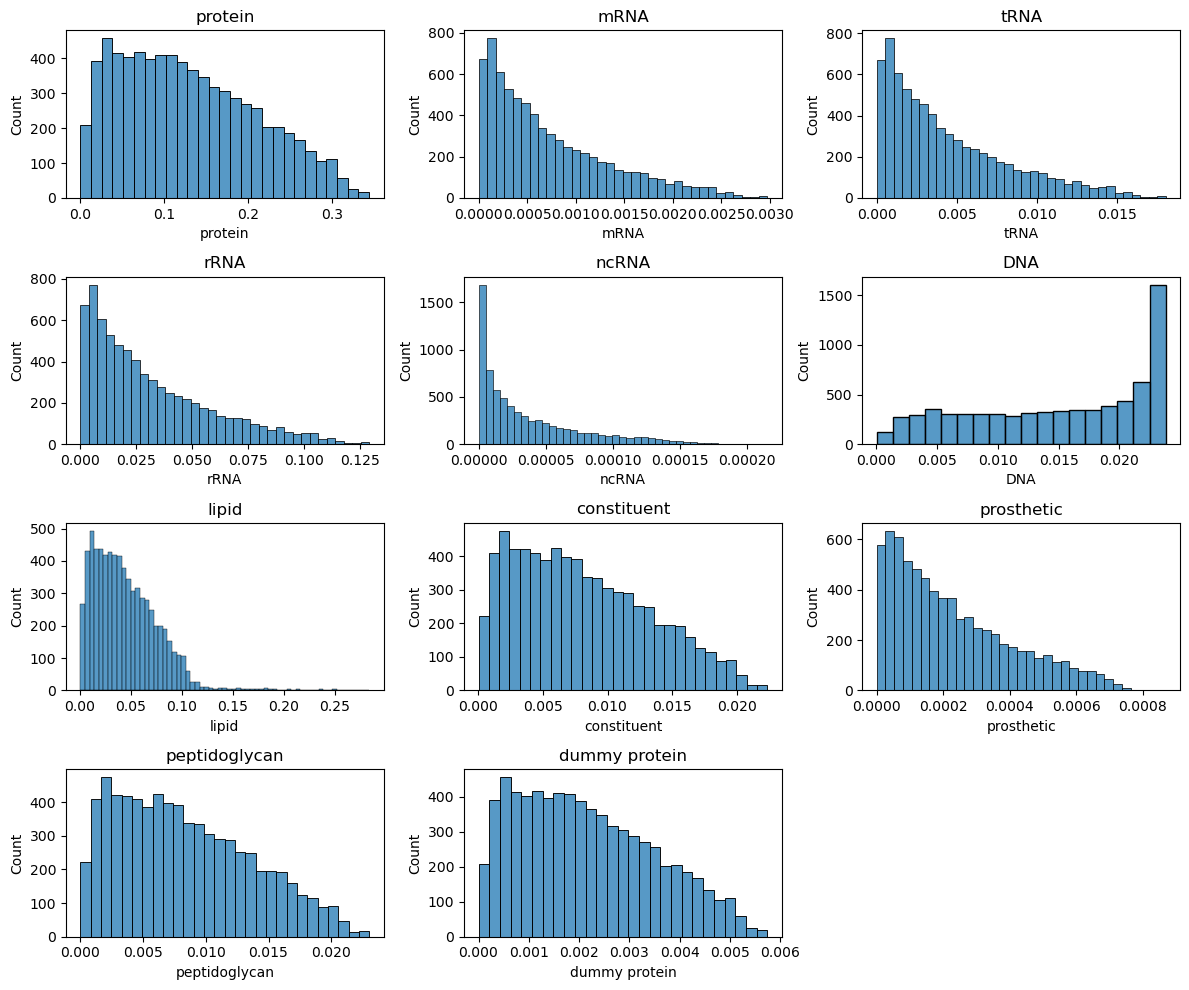

In [8]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(12, 10)
)

axes = axes.flatten()

for ax, col in zip(axes, bm_plot.columns):
    sns.histplot(
        bm_plot[col],
        ax=ax,
    )
    ax.set_title(col)

# remove empty subplot (since 4x3 = 12 but you have 11 columns)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [9]:
nitrogen_sources = [
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_ac', 'no3_glyc'
]

carbon_sources = ['glc', 'ac', 'lcts', 'glyc', 'succ']

bm_long = bm_plot.copy()
bm_long["source"] = data["source"].values

bm_long = bm_long.melt(
    id_vars="source",
    var_name="biomass_component",
    value_name="value"
)

bm_nitrogen = bm_long[bm_long["source"].isin(nitrogen_sources)]
bm_carbon = bm_long[bm_long["source"].isin(carbon_sources)]

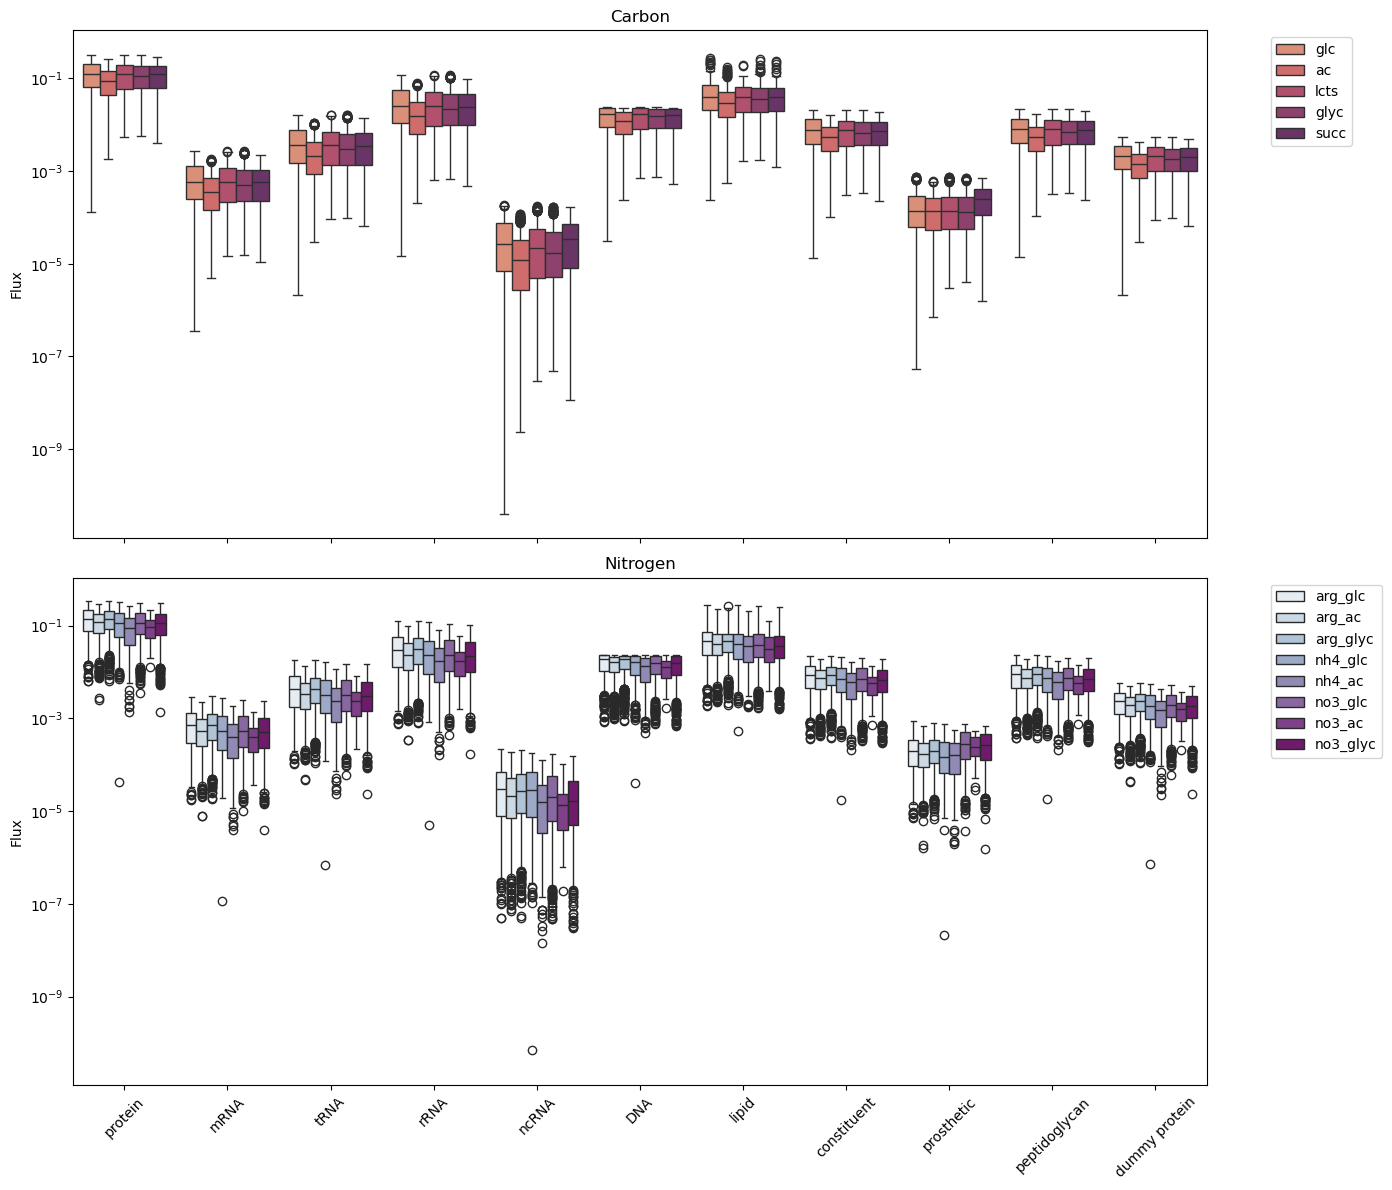

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharey=True)

sns.boxplot(
    data=bm_carbon,
    x="biomass_component",
    y="value",
    hue="source",
    ax=axes[0],
    palette="flare"
)

axes[0].set_xlabel("")
axes[0].set_ylabel('Flux')
axes[0].set_yscale('log')
axes[0].set_title("Carbon")
axes[0].set_xticklabels([])
axes[0].set_yscale('log')
axes[0].legend(bbox_to_anchor=(1.05, 1))

sns.boxplot(
    data=bm_nitrogen,
    x="biomass_component",
    y="value",
    hue="source",
    ax=axes[1],
    palette="BuPu"
)

axes[1].set_title("Nitrogen")
axes[1].set_ylabel('Flux')
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [7]:
color_map = sns.color_palette("crest", as_cmap=True)

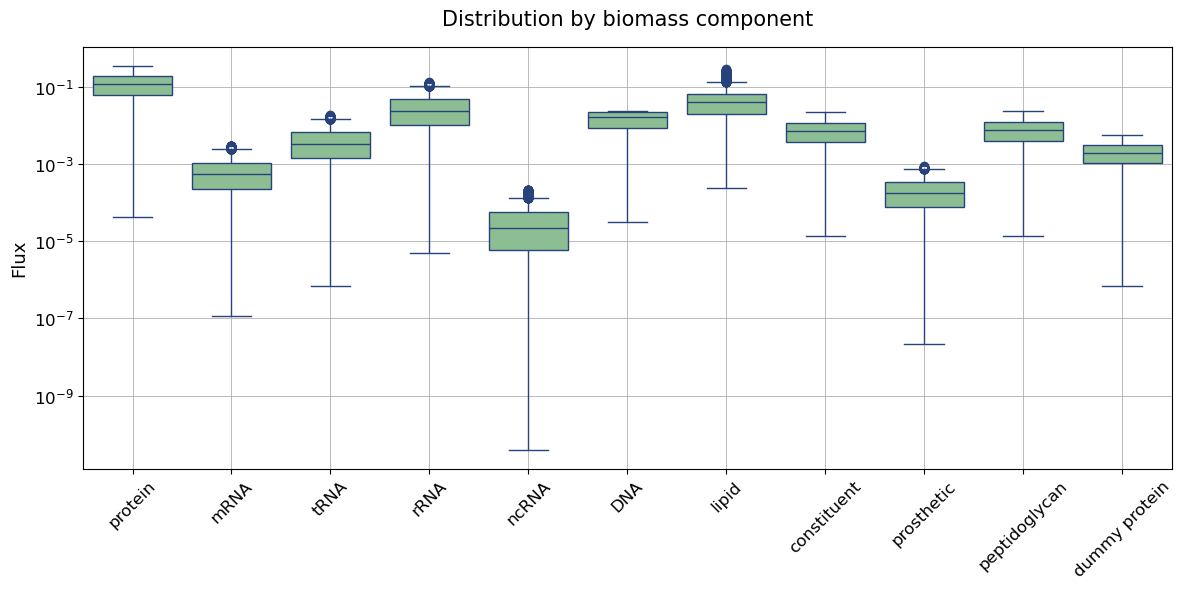

In [17]:
plt.figure(figsize=(12,6))

sns.boxplot(data=bm_plot, color=color_map(0.1), saturation=0.9, linecolor=color_map(0.9), linewidth=1.0)
plt.grid(True, linewidth=0.6)
plt.title("Distribution by biomass component", fontsize=15, pad=15)
plt.xlabel("")
plt.ylabel("Flux", fontsize=13)
plt.yscale("log")
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

## Correlation

In [28]:
corr = target_corr.corr(method='spearman')

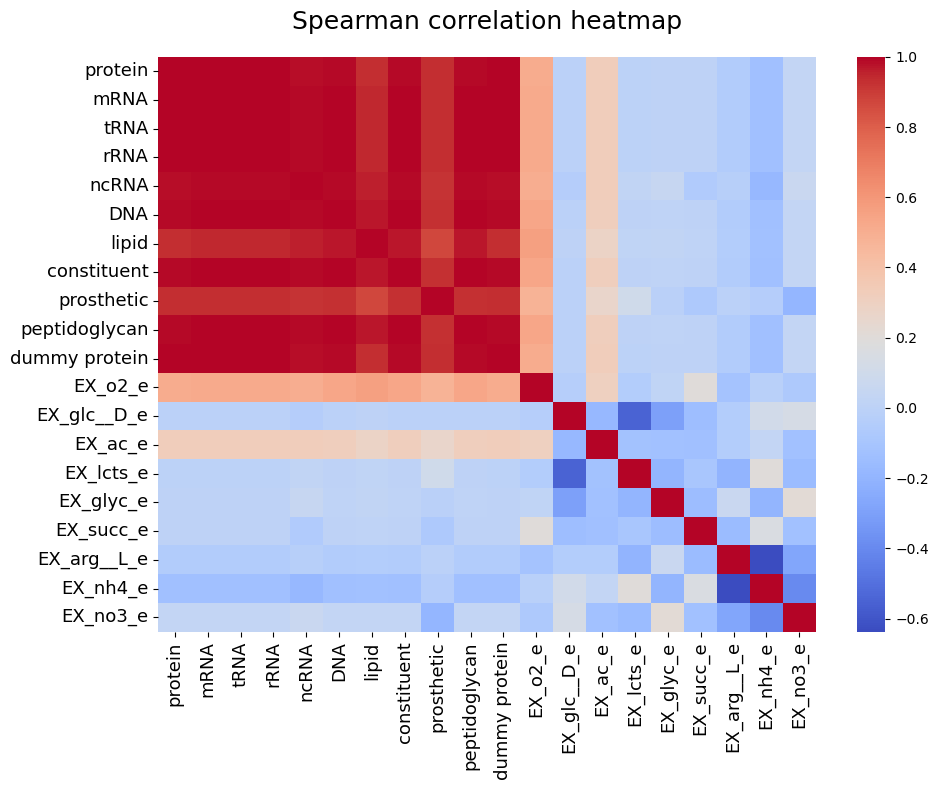

In [47]:
plt.figure(figsize=(10,8))

sns.heatmap(corr, cmap='coolwarm')

plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=90, fontsize=13)
plt.yticks(fontsize=13)
plt.title('Spearman correlation heatmap', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

## Component vs growth rate

In [219]:
color_map = sns.color_palette("GnBu", as_cmap=True)

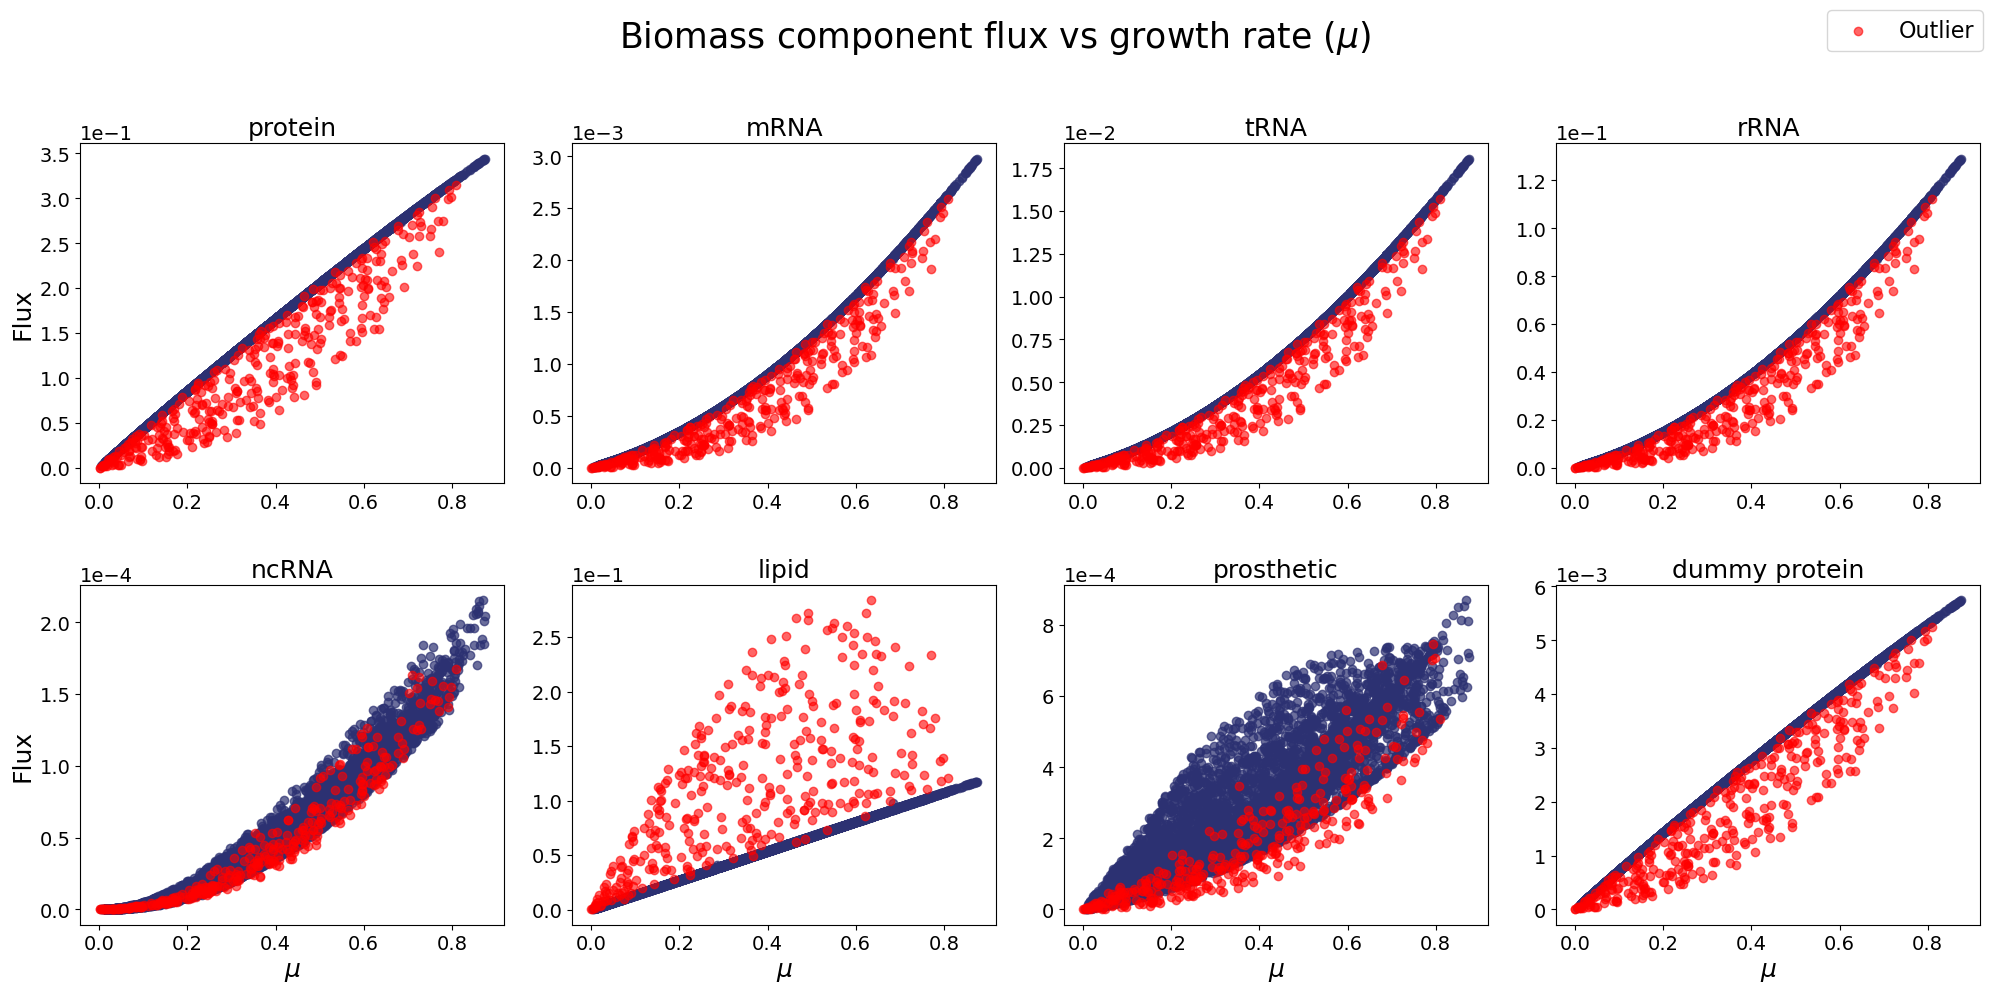

In [69]:
from matplotlib.ticker import ScalarFormatter

bm_plot_growth = bm_plot.copy()
bm_plot_growth = bm_plot_growth.drop(columns=['constituent', 'peptidoglycan', 'DNA'])
bm_plot_growth['biomass_dilution'] = data['biomass_dilution']

x_col = 'biomass_dilution'
y_cols = [col for col in bm_plot_growth.columns if col != x_col]

# Create mask (aligned with bm_plot_growth)
outlier_mask = data.loc[bm_plot_growth.index, 'outlier'] == 1

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, y_col in enumerate(y_cols):
    
    # Non-outliers (faint)
    axes[i].scatter(
        bm_plot_growth.loc[~outlier_mask, x_col],
        bm_plot_growth.loc[~outlier_mask, y_col],
        alpha=0.7,
        color=color_map(1.0)
    )
    
    # Outliers (highlighted)
    axes[i].scatter(
        bm_plot_growth.loc[outlier_mask, x_col],
        bm_plot_growth.loc[outlier_mask, y_col],
        alpha=0.6,
        color='red',
        label='Outlier' if i == 0 else None
    )

    axes[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[i].yaxis.get_offset_text().set_fontsize(14)
    axes[i].tick_params(axis='both', labelsize=14)

    axes[i].set_xlabel(r'$\mu$', fontsize=18)
    axes[i].set_ylabel(f'{y_col}')
    axes[i].set_title(y_col, fontsize=18)
    # axes[i].set_facecolor('floralwhite')

    

axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[2].set_xlabel("")
axes[3].set_xlabel("")

axes[0].set_ylabel("Flux", fontsize=18)
axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[3].set_ylabel("")

axes[4].set_ylabel("Flux", fontsize=18)
axes[5].set_ylabel("")
axes[6].set_ylabel("")
axes[7].set_ylabel("")


# Remove unused subplots
for j in range(len(y_cols), len(axes)):
    fig.delaxes(axes[j])

fig.legend(loc='upper right', fontsize=16)

plt.suptitle(r"Biomass component flux vs growth rate ($\mu$)", fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.3)
plt.show()

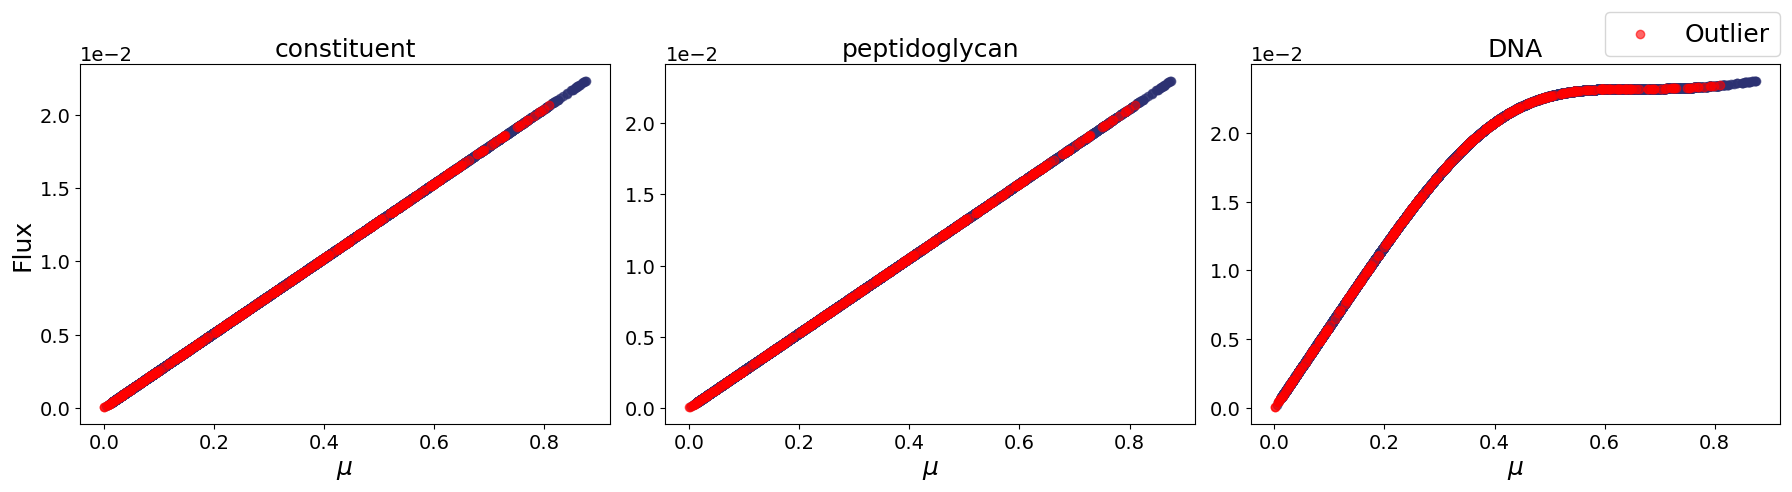

In [70]:
bm_plot_growth2 = bm_plot.copy()
bm_plot_growth2 = bm_plot_growth2[['constituent', 'peptidoglycan', 'DNA']]
bm_plot_growth2['biomass_dilution'] = data['biomass_dilution']

x_col = 'biomass_dilution'
y_cols = [col for col in bm_plot_growth2.columns if col != x_col]

# Create mask (aligned with bm_plot_growth)
outlier_mask = data.loc[bm_plot_growth2.index, 'outlier'] == 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, y_col in enumerate(y_cols):
    
    # Non-outliers (faint)
    axes[i].scatter(
        bm_plot_growth2.loc[~outlier_mask, x_col],
        bm_plot_growth2.loc[~outlier_mask, y_col],
        alpha=0.7,
        color=color_map(1.0)
    )
    
    # Outliers (highlighted)
    axes[i].scatter(
        bm_plot_growth2.loc[outlier_mask, x_col],
        bm_plot_growth2.loc[outlier_mask, y_col],
        alpha=0.6,
        color='red',
        label='Outlier' if i==0 else None
    )

    axes[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[i].yaxis.get_offset_text().set_fontsize(14)
    axes[i].tick_params(axis='both', labelsize=14)

    axes[i].set_xlabel(r'$\mu$', fontsize=18)
    axes[i].set_ylabel(f'{y_col}')
    axes[i].set_title(y_col, fontsize=18)
    # axes[i].set_facecolor('floralwhite')
    

axes[0].set_ylabel("Flux", fontsize=18)
axes[1].set_ylabel("")
axes[2].set_ylabel("")

# axes[1].set_yticklabels([])
# axes[2].set_yticklabels([])

# Remove unused subplots
for j in range(len(y_cols), len(axes)):
    fig.delaxes(axes[j])

fig.legend(loc='upper right', fontsize=18)
# plt.suptitle(r"Biomass component flux vs growth rate ($\mu$)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## PCA

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [28]:
color_map = sns.color_palette("crest", as_cmap=True)

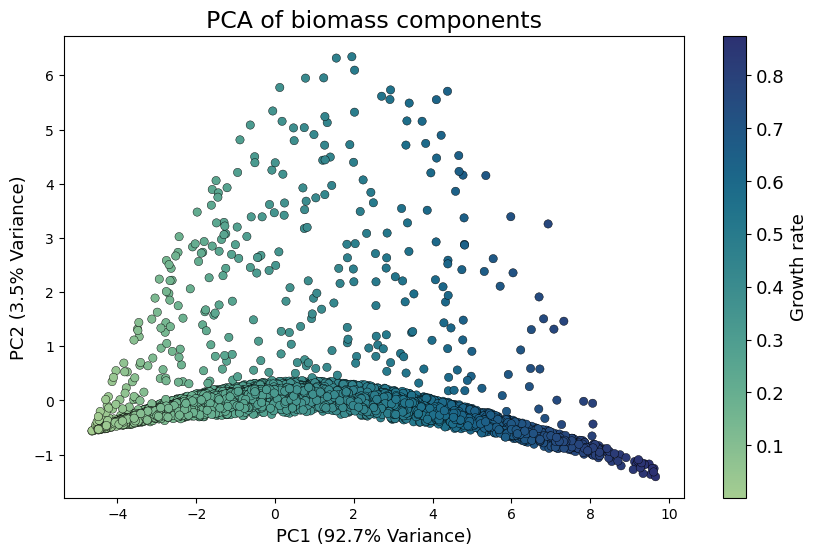

In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bm_plot)

pca = PCA(n_components=10)
scores = pca.fit_transform(X_scaled)
variance =  pca.explained_variance_ratio_


pca_df = pd.DataFrame({
    "PC1": scores[:, 0],
    "PC2": scores[:, 1],
    "biomass_dilution": data["biomass_dilution"].values
})

plt.figure(figsize=(10, 6))
sc = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['biomass_dilution'], cmap=color_map, edgecolors='black', linewidths=0.3)

cbar = plt.colorbar(sc)
cbar.set_label(label=r"Growth rate", fontsize=13)
cbar.ax.tick_params(labelsize=13)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)', fontsize=13)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)', fontsize=13)

# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

plt.title('PCA of biomass components', fontsize=17)
plt.show()

In [76]:
loadings = pd.DataFrame(
    pca.components_.T[:, :2],
    index=bm_plot.columns,
    columns=["PC1", "PC2"]
)


loadings = loadings.sort_values(by='PC1', ascending=False)
loadings = loadings.reset_index()
# loadings = loadings.reset_index().rename(columns={'index': 'Reaction'})

latex_loadings = loadings.to_latex(index=False, float_format="%.2f")
print(latex_loadings)

\begin{tabular}{lrr}
\toprule
reaction & PC1 & PC2 \\
\midrule
peptidoglycan & 0.31 & 0.07 \\
constituent & 0.31 & 0.07 \\
protein & 0.31 & -0.09 \\
dummy protein & 0.31 & -0.09 \\
tRNA & 0.31 & -0.18 \\
rRNA & 0.31 & -0.18 \\
mRNA & 0.31 & -0.18 \\
ncRNA & 0.30 & -0.16 \\
prosthetic & 0.29 & -0.25 \\
DNA & 0.29 & 0.31 \\
lipid & 0.26 & 0.83 \\
\bottomrule
\end{tabular}

